Level 2 -TASK 3 (K-CLUSTERING)
CUSTOMER SEGMENTATION USING K-MEANS CLUSTERING
Uncovering Telecom Customer Behaviour and Churn Pattern

In [13]:
#Importing the necessary libararies
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:
#Loading and displaying the dataset
df = pd.read_csv("churn_bigml_80.csv")
df.head(5)



,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [5]:
#Understanding the data
df.shape
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [ ]:
#Checking for duplicates
df.duplicated().sum()

0

In [7]:
df.corr(numeric_only=True)
#inspecting the numerical features

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
Account length,1.000000,-0.008620,-0.002996,0.002847,0.038862,0.002843,-0.015923,0.018552,-0.015909,-0.008994,-0.024007,-0.008999,0.011369,0.017627,0.011383,0.002455,0.017728
Area code,-0.008620,1.000000,-0.000584,-0.023134,-0.009629,-0.023130,0.000679,-0.018602,0.000707,-0.003353,0.011455,-0.003382,-0.013418,-0.027423,-0.013534,0.034442,0.001019
Number vmail messages,-0.002996,-0.000584,1.000000,0.019027,-0.009622,0.019027,0.011401,0.005131,0.011418,-0.000224,0.008124,-0.000229,-0.004156,0.027013,-0.004136,-0.018787,-0.086474
Total day minutes,0.002847,-0.023134,0.019027,1.000000,0.016780,1.000000,0.003999,0.009059,0.003992,0.013491,0.015054,0.013464,-0.011042,0.005687,-0.010934,-0.024543,0.195688
Total day calls,0.038862,-0.009629,-0.009622,0.016780,1.000000,0.016787,-0.026003,0.006473,-0.026006,0.008986,-0.016776,0.008972,0.031036,0.006928,0.031133,-0.011945,0.018290
Total day charge,0.002843,-0.023130,0.019027,1.000000,0.016787,1.000000,0.004008,0.009056,0.004002,0.013495,0.015057,0.013468,-0.011046,0.005688,-0.010938,-0.024548,0.195689
Total eve minutes,-0.015923,0.000679,0.011401,0.003999,-0.026003,0.004008,1.000000,-0.007654,1.000000,-0.013414,0.009017,-0.013450,-0.006915,0.002160,-0.006947,-0.013192,0.072906
Total eve calls,0.018552,-0.018602,0.005131,0.009059,0.006473,0.009056,-0.007654,1.000000,-0.007642,-0.000175,0.000797,-0.000135,0.011012,0.003710,0.011000,0.001058,-0.001539
Total eve charge,-0.015909,0.000707,0.011418,0.003992,-0.026006,0.004002,1.000000,-0.007642,1.000000,-0.013428,0.009030,-0.013464,-0.006923,0.002169,-0.006955,-0.013196,0.072893
Total night minutes,-0.008994,-0.003353,-0.000224,0.013491,0.008986,0.013495,-0.013414,-0.000175,-0.013428,1.000000,0.012736,0.999999,-0.008607,-0.001110,-0.008510,0.005236,0.033639


In [ ]:
#Creating a list of features to be used for clustering
features = [
    "Account length",
    "Number vmail messages",
    "Total day minutes",
    "Total day calls",
    "Total eve minutes",
    "Total night minutes",
    "Customer service calls"
]

X = df[features]

In [ ]:
#Displaying the first few rows of the feature matrix
X.head()
X.shape

(2666, 7)

In [ ]:
#Scaling the features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled.shape

X_scaled[:5]

array([[ 0.69216332,  1.24750838,  1.57966959,  0.48486775, -0.05861885,
         0.85740344, -0.42917241],
       [ 0.16127783,  1.32098526, -0.32991809,  1.13537472, -0.0959162 ,
         1.04845815, -0.42917241],
       [ 0.91968567, -0.58941354,  1.17930193,  0.68502374, -1.55443885,
        -0.75966782, -1.19195484],
       [-0.42016819, -0.58941354,  2.21250879, -1.46665316, -2.71850874,
        -0.08408263,  0.33361002],
       [-0.64769054, -0.58941354, -0.23582246,  0.63498474, -1.02246087,
        -0.28104624,  1.09639245]])

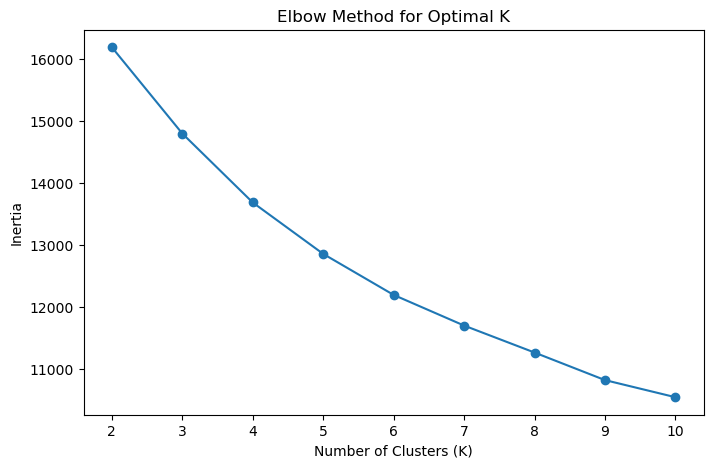

In [42]:
#Elbow method to find the optimal number of clusters
# Elbow method to find the optimal number of clusters

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

In [ ]:
#Silhouette analysis to find the optimal number of clusters
silhouette_scores = []

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

    print(f"K = {k}: Silhouette Score = {score:.3f}")

K = 2: Silhouette Score = 0.170
K = 3: Silhouette Score = 0.120
K = 4: Silhouette Score = 0.121
K = 5: Silhouette Score = 0.115
K = 6: Silhouette Score = 0.115


In [ ]:
# Final K-Means model with K=2
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

In [45]:
#Cluster distribution
df["Cluster"].value_counts().sort_index()

Cluster
0     709
1    1957
Name: count, dtype: int64

In [46]:
#Cluster summary
cluster_summary = df.groupby("Cluster")[features].mean()

cluster_summary

,Account length,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total night minutes,Customer service calls
Cluster,,,,,,,
0,100.574048,29.755994,181.444429,100.174894,202.158956,201.726093,1.524683
1,100.637200,0.147675,178.770516,100.359223,199.743894,200.967092,1.576392


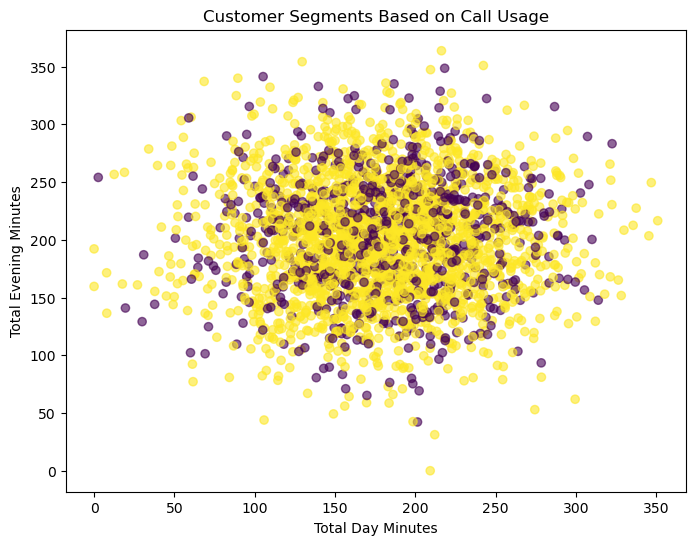

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Total day minutes"],
    df["Total eve minutes"],
    c=df["Cluster"],
    alpha=0.6
)

plt.xlabel("Total Day Minutes")
plt.ylabel("Total Evening Minutes")
plt.title("Customer Segments Based on Call Usage")

plt.show()

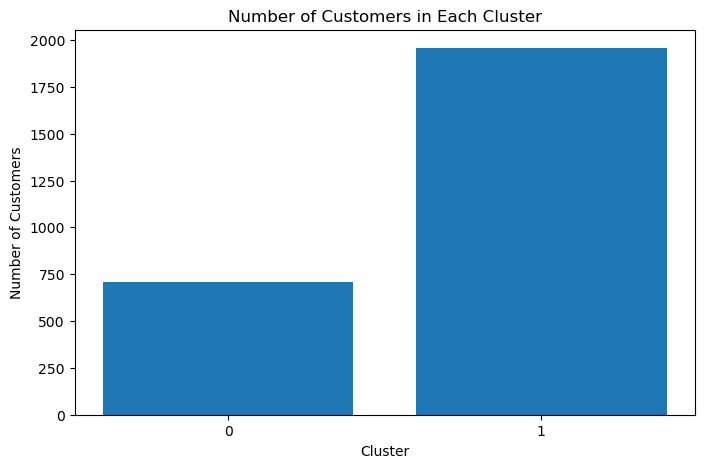

In [33]:
cluster_counts = df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Cluster")

plt.show()

In [34]:
churn_by_cluster = df.groupby("Cluster")["Churn"].mean() * 100

churn_by_cluster

Cluster
0     9.167842
1    16.504854
Name: Churn, dtype: float64

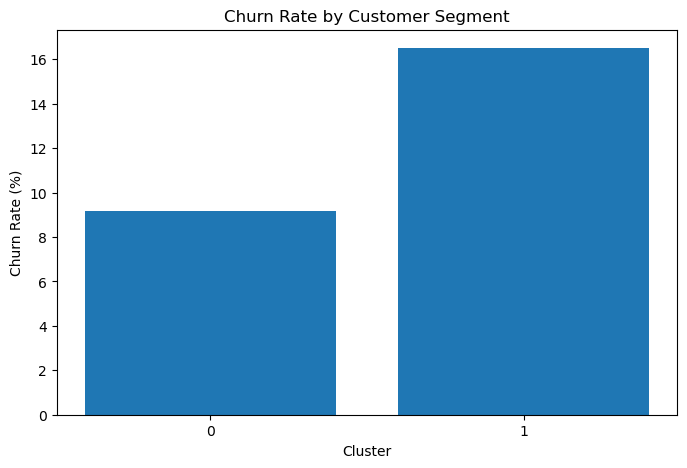

In [35]:
plt.figure(figsize=(8, 5))

plt.bar(
    churn_by_cluster.index.astype(str),
    churn_by_cluster.values
)

plt.xlabel("Cluster")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Customer Segment")

plt.show()

In [36]:
final_summary = df.groupby("Cluster").agg(
    Customers=("Cluster", "size"),
    Avg_Account_Length=("Account length", "mean"),
    Avg_Day_Minutes=("Total day minutes", "mean"),
    Avg_Eve_Minutes=("Total eve minutes", "mean"),
    Avg_Night_Minutes=("Total night minutes", "mean"),
    Avg_Service_Calls=("Customer service calls", "mean"),
    Churn_Rate=("Churn", "mean")
)

In [47]:
#Converting the churn rate to percentage and displaying the final summary
final_summary["Churn_Rate"] = final_summary["Churn_Rate"] * 100
final_summary
final_summary.round(2)


,Customers,Avg_Account_Length,Avg_Day_Minutes,Avg_Eve_Minutes,Avg_Night_Minutes,Avg_Service_Calls,Churn_Rate
Cluster,,,,,,,
0,709,100.57,181.44,202.16,201.73,1.52,91678.42
1,1957,100.64,178.77,199.74,200.97,1.58,165048.54


## Key Findings

- The K-Means model identified two customer segments.
- Cluster 0 contains 709 customers, while Cluster 1 contains 1,957 customers.
- The two segments have similar average call usage across several dimensions, but they differ substantially in voicemail usage.
- Cluster 0 has substantially higher average voicemail usage than Cluster 1.
- Cluster 1 has a higher churn rate than Cluster 0.
- The relatively low Silhouette Scores indicate that the two segments are not strongly separated, so the clusters should be interpreted as broad behavioral segments rather than completely distinct customer groups.

## Business Recommendations

Based on the customer segments identified:

1. The company should investigate why Cluster 1 has a higher churn rate and develop targeted retention strategies for this segment.

2. The company can use voicemail usage as one of the characteristics for understanding differences between customer segments.

3. Customers in higher-churn segments should be monitored more closely and offered targeted support or incentives.

4. Future analysis should investigate additional customer characteristics, including plan type and international usage, to better understand the drivers of churn.